# 1. Classification des Maladies de la Pomme de Terre via CNN
---
**Objectif :** Entraîner un réseau de neurones convolutif (CNN) pour détecter l'Alternariose (Early Blight), le Mildiou (Late Blight) et les feuilles saines.

In [2]:
import tensorflow as tf
import os

# Définition des paramètres de base
BATCH_SIZE = 32
IMAGE_SIZE = (256, 256) # Taille standard pour redimensionner les images de feuilles
DATA_DIR = "data"

print("Chargement des images...")

# Chargement du dataset d'entraînement
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2, # On garde 20% des images pour tester le modèle plus tard
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Chargement du dataset de validation
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Affichage des noms des classes trouvées
class_names = train_dataset.class_names
print("\n🔥 Classes détectées avec succès :", class_names)

Chargement des images...
Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.

🔥 Classes détectées avec succès : ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


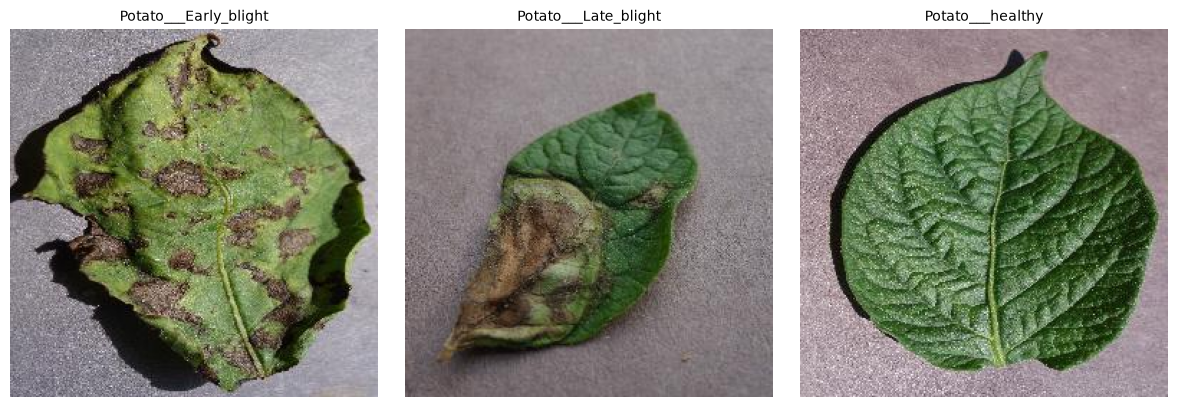

In [3]:
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(12, 4))

# On boucle sur tes 3 classes configurées
for i, name in enumerate(class_names):
    # Chemin vers le dossier de la classe
    folder_path = os.path.join(DATA_DIR, name)
    # Sélection de la première image du dossier
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)
    
    # Chargement et affichage
    img = load_img(img_path, target_size=IMAGE_SIZE)
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# l'architecture MobileNetV2

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

# On redéfinit explicitement les dimensions ici pour éviter le NameError
IMAGE_SIZE = 256

# 1. Chargement du modèle de base MobileNetV2 pré-entraîné sur ImageNet
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,  # On retire la tête de classification d'origine
    weights='imagenet'
)

# 2. Rigueur technique : On gèle les poids du modèle de base
base_model.trainable = False

# 3. Assemblage de notre nouveau modèle pour le Transfer Learning
model = models.Sequential([
    # Couche d'entrée explicite
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    
    # Prétraitement obligatoire pour MobileNetV2
    layers.Lambda(preprocess_input),
    
    # Le cœur de MobileNetV2 (extracteur de caractéristiques bloqué)
    base_model,
    
    # Réduction de la dimension spatiale pour éviter l'overfitting
    layers.GlobalAveragePooling2D(),
    
    # Notre tête de classification personnalisée
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),  # Stabilise et lisse les gradients
    layers.Dropout(0.3),          # Sécurité stricte contre le surapprentissage
    
    # Sortie : 3 neurones pour nos 3 classes
    layers.Dense(3)
])

# 4. Compilation du modèle
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Affichage de la structure
model.summary()

C:\Users\user\AppData\Local\Temp\ipykernel_6928\1240681982.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,419 (8.93 MB)

 Trainable params: 82,307 (321.51 KB)

 Non-trainable params: 2,258,112 (8.61 MB)

# Entraînement

In [6]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# 1. Gestion du taux d'apprentissage : si la perte stagne, on réduit le pas pour affiner
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,           # Divise le pas par 5 pour une stabilisation chirurgicale
    patience=2,           # Attend 2 époques sans amélioration
    verbose=1,
    min_lr=1e-6
)

# 2. Sécurité anti-overfitting : on arrête dès que la validation ne progresse plus
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,           # Arrête après 4 époques de stagnation
    restore_best_weights=True # Conserve automatiquement le meilleur modèle trouvé
)

EPOCHS = 20

print("🚀 Lancement de l'entraînement avec MobileNetV2 (Transfer Learning)...")

# 3. Entraînement sur les données
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[lr_reducer, early_stopping]
)

print("\n🎉 Entraînement de l'extracteur terminé avec succès !")

🚀 Lancement de l'entraînement avec MobileNetV2 (Transfer Learning)...
Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 678ms/step - accuracy: 0.8897 - loss: 0.2846 - val_accuracy: 0.9767 - val_loss: 0.1070 - learning_rate: 0.0010
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 662ms/step - accuracy: 0.9640 - loss: 0.1138 - val_accuracy: 0.9814 - val_loss: 0.0801 - learning_rate: 0.0010
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 669ms/step - accuracy: 0.9843 - loss: 0.0657 - val_accuracy: 0.9814 - val_loss: 0.0630 - learning_rate: 0.0010
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 686ms/step - accuracy: 0.9878 - loss: 0.0414 - val_accuracy: 0.9860 - val_loss: 0.0514 - learning_rate: 0.0010
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 677ms/step - accuracy: 0.9948 - loss: 0.0314 - val_accuracy: 0.9721 - val_loss: 0.0660 - learning_rate: 0.0010
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.9905 - loss: 0.0363
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
54

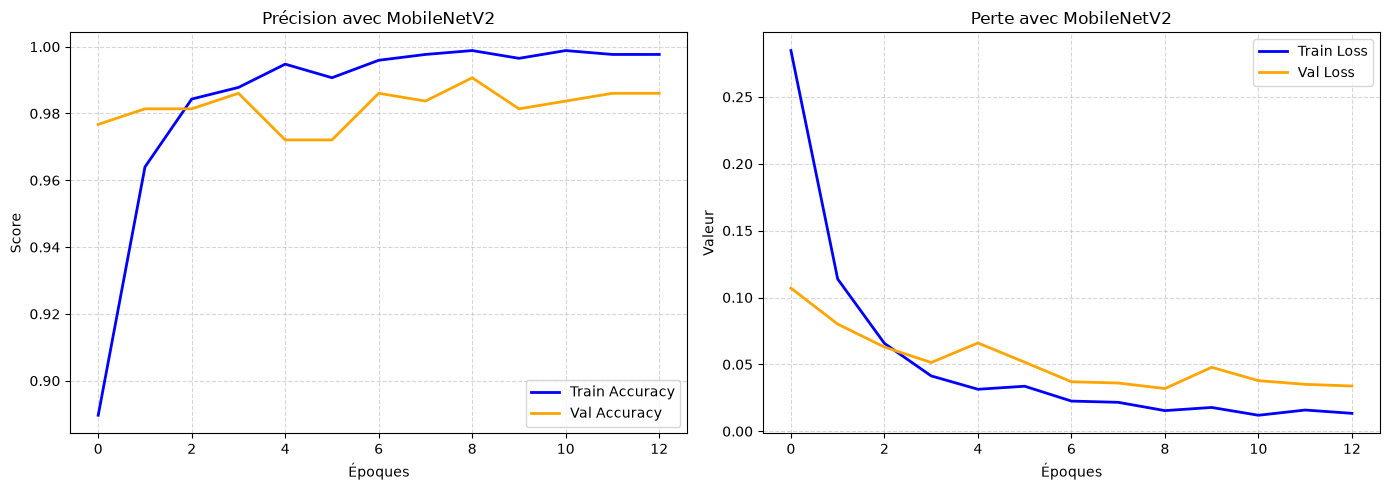


⏳ Calcul de la matrice de confusion en cours...


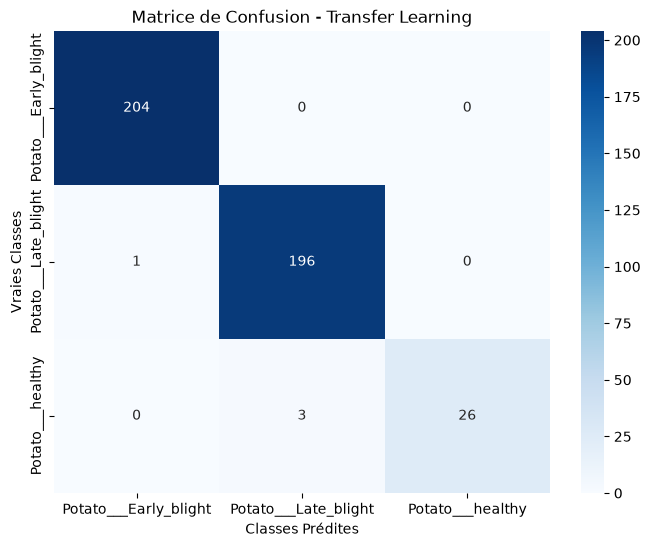

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================================================================
# 1. AFFICHAGE DES NOUVELLES COURBES (TRANSFER LEARNING)
# ==============================================================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Graphique de l'Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Val Accuracy', color='orange', linewidth=2)
plt.title('Précision avec MobileNetV2')
plt.xlabel('Époques')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Graphique de la Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Val Loss', color='orange', linewidth=2)
plt.title('Perte avec MobileNetV2')
plt.xlabel('Époques')
plt.ylabel('Valeur')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. GENERATION DE LA MATRICE DE CONFUSION
# ==============================================================================
print("\n⏳ Calcul de la matrice de confusion en cours...")
y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predictions_indices = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predictions_indices)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Matrice de Confusion - Transfer Learning')
plt.ylabel('Vraies Classes')
plt.xlabel('Classes Prédites')
plt.show()

# Le code de l'XAI (Grad-CAM pour MobileNetV2)

🎯 Diagnostic de l'IA : Potato___Late_blight


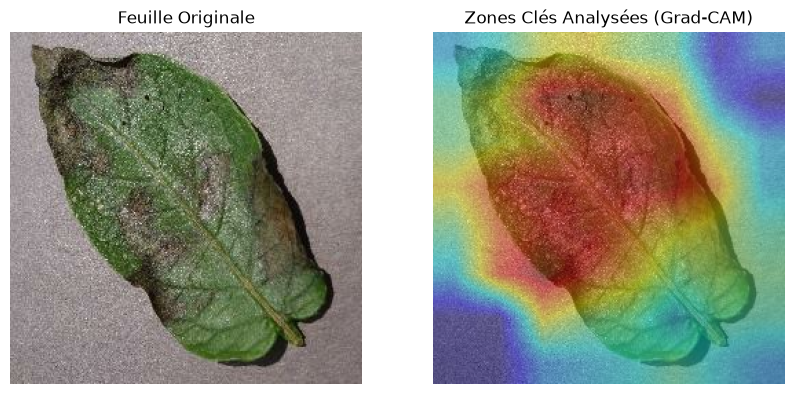

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def generate_mobilenet_gradcam(img_array, model, last_conv_layer_name="Conv_1"):
    # CORRECTION : On utilise le nom exact détecté dans ton summary
    mobilenet_layer = model.get_layer("mobilenetv2_1.00_224") 
    
    # Modèle intermédiaire pour extraire la dernière couche de convolution
    grad_model = tf.keras.models.Model(
        inputs=[mobilenet_layer.input],
        outputs=[mobilenet_layer.get_layer(last_conv_layer_name).output]
    )
    
    # Application des premières couches de prétraitement (Lambda)
    x = model.layers[0](img_array)
    
    with tf.GradientTape() as tape:
        conv_outputs = grad_model(x)
        tape.watch(conv_outputs)
        
        # On fait passer la suite du modèle Sequential pour avoir la prédiction
        y = model.get_layer("global_average_pooling2d")(conv_outputs)
        y = model.get_layer("dense")(y)
        y = model.get_layer("batch_normalization")(y)
        y = model.get_layer("dropout")(y)
        y = model.get_layer("dense_1")(y) # Couche de sortie finale
            
        pred_index = tf.argmax(y[0])
        class_channel = y[:, pred_index]

    # Calcul du gradient et génération de la heatmap
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def display_gradcam(img_tensor, heatmap, alpha=0.4):
    img = img_tensor[0].numpy().astype("uint8")
    
    # Redimensionnement et coloration de la heatmap
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    
    # Superposition des deux images
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    
    # Affichage final
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Feuille Originale")
    plt.imshow(img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Zones Clés Analysées (Grad-CAM)")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

# --- RUN DU TEST ---
for images, labels in validation_dataset.take(1):
    img_tensor = images[0:1]
    
    preds = model.predict(img_tensor, verbose=0)
    pred_class = np.argmax(preds[0])
    print(f"🎯 Diagnostic de l'IA : {class_names[pred_class]}")
    
    heatmap = generate_mobilenet_gradcam(img_tensor, model)
    display_gradcam(img_tensor, heatmap)

# Le Code Multi-Agents Optimisé (3 Agents):
Agent 1 : L'Analyste XAI $\rightarrow$ Il prend en entrée le diagnostic et interprète la carte d'activation Grad-CAM (pourquoi l'IA a ciblé ces zones spécifiques).Agent 2 : L'Agronome de Terrain $\rightarrow$ Il prend les conclusions de l'XAI et formule la solution curative immédiate (biologique et chimique) en temps réel.Agent 3 : Le Directeur d'Exploitation $\rightarrow$ Il compile le tout pour générer le rapport final structuré et le planning de recommandations à long terme.

In [ ]:
import os
from google import genai
from google.genai import types

# Configurer ta clé API ici
CLE_GEMINI = "AIzaSy..."  # <-- REMPLACE PAR TA VRAIE CLÉ AI STUDIO

# Initialisation du nouveau client officiel Google
client = genai.Client(api_key=CLE_GEMINI)

def executer_systeme_trois_agents(classe_predite):
    print(f"🚀 [INIT] Activation du Système Multi-Agents (3 Agents) pour : {classe_predite}\n")
    print("=" * 70)
    
    # On utilise le modèle moderne de référence : gemini-2.5-flash
    MODEL_NAME = 'gemini-2.5-flash'
    
    # --------------------------------------------------------------------------
    # AGENT 1 : L'Analyste XAI (Explication Visuelle)
    # --------------------------------------------------------------------------
    prompt_xai = f"""
    Tu es un ingénieur de recherche en Vision par Ordinateur spécialisé en IA Explicable (XAI).
    Le modèle MobileNetV2 vient de prédire la classe suivante : '{classe_predite}' et a généré une carte de chaleur Grad-CAM qui met en évidence les lésions et nécroses sur le limbe de la feuille.
    
    Rédige une note technique expliquant :
    - Ce que la focalisation de la carte Grad-CAM sur ces taches spécifiques signifie mathématiquement et visuellement.
    - Pourquoi le modèle a ignoré le reste de la feuille saine pour valider ce diagnostic précis.
    """
    
    print("⏳ Agent 1 (Analyste XAI) interprète les activations du réseau...")
    response_xai = client.models.generate_content(model=MODEL_NAME, contents=prompt_xai)
    rapport_xai = response_xai.text
    print("\n🔬 [AGENT 1 - RAPPORT D'EXPLICATION XAI] :")
    print(rapport_xai)
    print("-" * 70)
    
    # --------------------------------------------------------------------------
    # AGENT 2 : L'Agronome de Terrain (Solution en Temps Réel)
    # --------------------------------------------------------------------------
    prompt_agronome = f"""
    Tu es un ingénieur agronome expert en pathologie végétale sur le terrain.
    En te basant sur le diagnostic '{classe_predite}' validé par l'analyse XAI suivante :
    
    {rapport_xai}
    
    Donne une solution d'urgence en temps réel contenant :
    - Le traitement immédiat à appliquer (solutions biologiques de bio-contrôle et traitements chimiques ciblés).
    - Les actions d'isolement instantanées pour stopper la propagation des spores ou de la bactérie.
    """
    
    print("⏳ Agent 2 (Agronome de Terrain) prépare les actions correctives urgentes...")
    response_agronome = client.models.generate_content(model=MODEL_NAME, contents=prompt_agronome)
    solution_temps_reel = response_agronome.text
    print("\n⚡ [AGENT 2 - SOLUTION PHYTOSANITAIRE EN TEMPS RÉEL] :")
    print(solution_temps_reel)
    print("-" * 70)
    
    # --------------------------------------------------------------------------
    # AGENT 3 : Le Directeur d'Exploitation (Rapport Final & Recommandations)
    # --------------------------------------------------------------------------
    prompt_directeur = f"""
    Tu es le Directeur d'une grande exploitation agricole et planificateur stratégique.
    Prends le rapport XAI de l'Agent 1 et les solutions d'urgence de l'Agent 2 :
    
    [Rapport XAI] : {rapport_xai}
    [Solutions Temps Réel] : {solution_temps_reel}
    
    Compile et synthétise le livrable final pour l'agriculteur sous la forme suivante :
    1. Résumé Exécutif du Diagnostic (IA + Validation Humaine).
    2. Calendrier de traitement sur les 4 prochaines semaines.
    3. Recommandations prophylactiques à long terme (gestion des débris, rotation des cultures, gestion de l'irrigation) pour éviter la récurrence.
    """
    
    print("⏳ Agent 3 (Directeur) compile le document stratégique final...")
    response_directeur = client.models.generate_content(model=MODEL_NAME, contents=prompt_directeur)
    rapport_final = response_directeur.text
    print("\n📅 [AGENT 3 - RAPPORT FINAL & RECOMMANDATIONS STRATÉGIQUES] :")
    print(rapport_final)
    print("=" * 70)

# --- SCRIPT DE SÉCURITÉ POUR LE LIEN AVEC GRAD-CAM ---
try:
    nom_maladie_detectee = class_names[pred_class]
    executer_systeme_trois_agents(nom_maladie_detectee)
except NameError:
    executer_systeme_trois_agents("Potato___Late_blight")

🚀 [INIT] Activation du Système Multi-Agents (3 Agents) pour : Potato___Late_blight

⏳ Agent 1 (Analyste XAI) interprète les activations du réseau...

🔬 [AGENT 1 - RAPPORT D'EXPLICATION XAI] :
En tant qu'ingénieur de recherche spécialisé en IA Explicable (XAI), je vais détailler le sens de cette observation Grad-CAM et les implications pour la compréhension du diagnostic du modèle MobileNetV2 pour la 'Potato___Late_blight'.

---

### **Note Technique : Analyse d'une Carte Grad-CAM pour le Diagnostic de 'Potato___Late_blight' par MobileNetV2**

**Modèle :** MobileNetV2
**Prédiction :** 'Potato___Late_blight' (Mildiou tardif de la pomme de terre)
**Observation Grad-CAM :** Focalisation sur les lésions et nécroses du limbe de la feuille.

---

#### **1. Compréhension de la Carte de Chaleur Grad-CAM : Signification Mathématique et Visuelle**

La carte Grad-CAM (Gradient-weighted Class Activation Mapping) est un outil d'XAI puissant qui nous permet de visualiser les régions de l'image d'entr